<a href="https://colab.research.google.com/github/DhimanTarafdar/gallbladder_cancer_research/blob/main/Gallbladder_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install** and load required packages

In [1]:
!pip install rpy2 --quiet

import pandas as pd
import numpy as np
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, numpy2ri, r
from rpy2.robjects.packages import importr

# Install R packages (only needs to run once per session)
robjects.r('''
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager", repos="http://cran.r-project.org")
BiocManager::install(c("limma", "edgeR"), update = FALSE, ask = FALSE)
''')

limma = importr('limma')
pandas2ri.activate()
numpy2ri.activate()
print("Setup done ✅")

(as ‘lib’ is unspecified)







	‘/tmp/Rtmpte2y4p/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com











	‘/tmp/Rtmpte2y4p/downloaded_packages’



Setup done ✅


# **Load GSE139682 (normalized RPKM data)**

In [2]:
df_139682 = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')

# Get normal and tumor sample columns automatically
normal_cols_139682 = [c for c in df_139682.columns if c.startswith('Normal')]
tumor_cols_139682  = [c for c in df_139682.columns if c.startswith('Tumor')]

print(f"GSE139682 -> Normal: {len(normal_cols_139682)}, Tumor: {len(tumor_cols_139682)}")

GSE139682 -> Normal: 10, Tumor: 10


# **Load GSE202479 (raw count data) + build labels**

In [5]:
def extract_full_metadata_line(series_matrix_path, keyword):
    # This function reads one metadata line from the series_matrix file
    with open(series_matrix_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(keyword):
                parts = line.strip().split('\t')
                parts = [p.strip('"') for p in parts]
                return parts[1:]  # skip the label, keep only values
    return None

import re

titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

# Map sample code (like N8, T1) to normal/tumor/exclude
label_map_202479 = {}
for title, tissue in zip(titles, tissue_type):
    code = re.search(r'\[(.*?)\]', title).group(1)
    tissue_clean = tissue.replace('tissue type: ', '').strip()
    if tissue_clean == 'normal gallbladder':
        label_map_202479[code] = 'normal'
    elif tissue_clean == 'advanced gallbladder cancer':
        label_map_202479[code] = 'tumor'
    else:
        label_map_202479[code] = 'exclude'   # skip inflammation, adenoma, early stage

# Build final column lists
normal_codes = [k for k, v in label_map_202479.items() if v == 'normal']
tumor_codes  = [k for k, v in label_map_202479.items() if v == 'tumor']

normal_cols_202479 = [f"{c}_count" for c in normal_codes]
tumor_cols_202479  = [f"{c}_count" for c in tumor_codes]

df_202479 = pd.read_csv('GSE202479_gene_expression_anno.txt', sep='\t')

print(f"GSE202479 -> Normal: {len(normal_cols_202479)}, Tumor: {len(tumor_cols_202479)}")

GSE202479 -> Normal: 3, Tumor: 5


In [6]:
selected_cols = ['Gene', 'Symbol'] + normal_cols_202479 + tumor_cols_202479

print(df_202479[normal_cols_202479 + tumor_cols_202479].head())

   N8_count  N10_count  N20_count  T1_count  T19_count  T22_count  T27_count  \
0         0          0          0         0          0          0          0   
1        86         56        175        25         30         42         38   
2      1176        975       1705      1151       1253       1631       1334   
3      1717       1582       2262      2152       1397       1729       3035   
4         3          2          5         1          0          4          7   

   T32_count  
0          0  
1         84  
2       1238  
3       4213  
4          0  


In [8]:
print("Dataset Shape:", df_202479.shape)


Dataset Shape: (50868, 50)


# **DEG analysis functions**

In [10]:
def run_limma_normalized(expr_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    # Use this for already-normalized data (like RPKM/FPKM)
    expr_matrix = expr_df[normal_cols + tumor_cols].values
    expr_matrix = np.log2(expr_matrix + 1)  # log transform, avoid log(0)

    genes = expr_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    r.assign('expr_mat', expr_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(expr_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)
    fit <- lmFit(expr_mat, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested")
    return result_df


def run_limma_voom(count_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    # Use this for raw count data
    count_matrix = count_df[normal_cols + tumor_cols].values
    genes = count_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    r.assign('count_mat', count_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(count_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)

    library(edgeR)
    dge <- DGEList(counts=count_mat)
    keep <- filterByExpr(dge, design)
    dge <- dge[keep,, keep.lib.sizes=FALSE]
    dge <- calcNormFactors(dge)

    v <- voom(dge, design)
    fit <- lmFit(v, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested (after low-expression filter)")
    return result_df

# **Run DEG analysis on both datasets**

In [11]:
deg_139682 = run_limma_normalized(df_139682, 'GeneID', normal_cols_139682, tumor_cols_139682, "GSE139682")
deg_202479 = run_limma_voom(df_202479, 'gene_id', normal_cols_202479, tumor_cols_202479, "GSE202479")

GSE139682: 41762 genes tested


GSE202479: 21273 genes tested (after low-expression filter)


# **Filter significant DEGs**

In [12]:
def filter_significant_degs(deg_df, logfc_col='logFC', padj_col='adj.P.Val',
                              logfc_thresh=1, padj_thresh=0.05):
    # Keep only genes that are statistically significant AND have a strong fold change
    sig = deg_df[(deg_df[padj_col] < padj_thresh) & (deg_df[logfc_col].abs() > logfc_thresh)]
    print(f"Significant DEGs: {sig.shape[0]} out of {deg_df.shape[0]}")
    return sig

sig_139682 = filter_significant_degs(deg_139682)
sig_202479 = filter_significant_degs(deg_202479)

Significant DEGs: 650 out of 41762
Significant DEGs: 1033 out of 21273


# **Map all gene IDs to Symbol (common gene naming system)**

In [14]:
df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t', low_memory=False)
ensembl_to_symbol = dict(zip(df_annot['EnsemblGeneID'], df_annot['Symbol']))

# GSE139682 already uses Symbol, no conversion needed
sig_139682_genes = set(sig_139682['GeneID'])

# GSE202479 uses Ensembl ID, convert to Symbol
sig_202479_genes = set(sig_202479['GeneID'].map(ensembl_to_symbol).dropna())

print(f"GSE139682 mapped genes: {len(sig_139682_genes)}")
print(f"GSE202479 mapped genes: {len(sig_202479_genes)}")

GSE139682 mapped genes: 650
GSE202479 mapped genes: 879


# **Find consensus DEGs (final feature pool)**

In [16]:
consensus_genes = sig_139682_genes & sig_202479_genes
print(f"\nFinal consensus DEG pool: {len(consensus_genes)} genes")
print(sorted(consensus_genes))

# Save this list -- this is the input for the next stage (ML feature selection)
consensus_df = pd.DataFrame({'Gene_Symbol': sorted(consensus_genes)})
consensus_df.to_csv('consensus_DEG_list.csv', index=False)
print("\nSaved consensus DEG list to 'consensus_DEG_list.csv'")


Final consensus DEG pool: 178 genes
['ABCA8', 'ABI3BP', 'ACSS3', 'ACTC1', 'ACTG2', 'ADAMTS1', 'ADAMTS8', 'ADAMTS9-AS2', 'ADCY5', 'ADRB3', 'AKAP6', 'ANGPT1', 'ANGPTL1', 'ANLN', 'AOX1', 'ARHGEF26', 'ASB2', 'ATAD2', 'ATOH8', 'ATP1A2', 'BIRC5', 'BUB1', 'C3orf70', 'CAB39L', 'CASQ2', 'CCDC3', 'CCKAR', 'CDH19', 'CDO1', 'CENPF', 'CFD', 'CHRM2', 'CKS2', 'CLEC3B', 'CLIP3', 'CNN1', 'CNTN1', 'COL4A6', 'CRYAB', 'CSPG4', 'DIAPH3', 'DIXDC1', 'DMD', 'DPT', 'DTNA', 'E2F1', 'ECT2', 'EFCC1', 'EFHD1', 'EML1', 'EPPK1', 'EVPL', 'EXO1', 'EZH2', 'FAM107A', 'FAM162B', 'FAXDC2', 'FCER1A', 'FENDRR', 'FGF2', 'FHL1', 'FILIP1', 'FOXF1', 'FREM1', 'FXYD1', 'FXYD6', 'GALNT16', 'GFRA1', 'GINS1', 'GLP2R', 'GPM6A', 'GPM6B', 'GPRASP1', 'GPX3', 'GUCY1B2', 'HBB', 'HDC', 'HLF', 'HMMR', 'HOXB5', 'HOXB7', 'HPSE2', 'HSPB6', 'HSPB7', 'HSPB8', 'IQGAP3', 'ITGA7', 'ITGA8', 'ITPR1', 'JPH2', 'KANK2', 'KCNAB1', 'KCNMA1', 'KCNMB1', 'KIF14', 'KIF18B', 'KIF4A', 'KLF15', 'KRT222', 'LAMB3', 'LIFR', 'LIMS2', 'LMOD1', 'MADCAM1', 'MAMDC2', '

# **Build combined expression matrix for the 178 consensus genes**

In [17]:
import pandas as pd
import numpy as np

# Load the consensus gene list
consensus_df = pd.read_csv('consensus_DEG_list.csv')
consensus_genes = consensus_df['Gene_Symbol'].tolist()
print(f"Total consensus genes: {len(consensus_genes)}")

# ---- GSE139682: already uses gene Symbol, so filter directly ----
expr_139682 = df_139682[df_139682['GeneID'].isin(consensus_genes)].copy()
expr_139682 = expr_139682.set_index('GeneID')[normal_cols_139682 + tumor_cols_139682]
expr_139682 = np.log2(expr_139682 + 1)   # log transform, same as DEG step

# ---- GSE202479: uses Ensembl ID, convert to Symbol first ----
df_202479_annot = df_202479.copy()
df_202479_annot['Symbol'] = df_202479_annot['gene_id'].map(ensembl_to_symbol)
expr_202479 = df_202479_annot[df_202479_annot['Symbol'].isin(consensus_genes)].copy()
expr_202479 = expr_202479.drop_duplicates(subset='Symbol')  # keep first if duplicate mapping
expr_202479 = expr_202479.set_index('Symbol')[normal_cols_202479 + tumor_cols_202479]
expr_202479 = np.log2(expr_202479 + 1)

print(f"GSE139682 matched genes: {expr_139682.shape[0]}")
print(f"GSE202479 matched genes: {expr_202479.shape[0]}")

# ---- Align gene order (keep only genes present in both, in same order) ----
common_genes = sorted(set(expr_139682.index) & set(expr_202479.index))
expr_139682 = expr_139682.loc[common_genes]
expr_202479 = expr_202479.loc[common_genes]
print(f"Genes present in both (final feature set): {len(common_genes)}")

# ---- Merge into one matrix (samples as rows, genes as columns) ----
combined_expr = pd.concat([expr_139682, expr_202479], axis=1).T
combined_expr['label'] = ['normal']*len(normal_cols_139682) + ['tumor']*len(tumor_cols_139682) + \
                          ['normal']*len(normal_cols_202479) + ['tumor']*len(tumor_cols_202479)
combined_expr['batch'] = ['GSE139682']*len(normal_cols_139682+tumor_cols_139682) + \
                          ['GSE202479']*len(normal_cols_202479+tumor_cols_202479)

print(combined_expr.shape)
combined_expr.head()

Total consensus genes: 178
GSE139682 matched genes: 178
GSE202479 matched genes: 178
Genes present in both (final feature set): 178
(28, 180)


,ABCA8,ABI3BP,ACSS3,ACTC1,ACTG2,ADAMTS1,ADAMTS8,ADAMTS9-AS2,ADCY5,ADRB3,...,TOP2A,TPX2,TRIP13,TTK,TUB,VIT,WFDC1,ZNF385D,label,batch
Normal 6,4.942227,5.205296,3.202292,1.326892,7.677738,7.581749,2.592949,3.564315,3.410379,2.353998,...,1.524688,1.418743,0.809668,0.622396,2.606595,1.734507,4.547673,2.871262,normal,GSE139682
Normal 10,4.371806,4.808659,3.238318,2.245756,7.289556,4.631507,1.715462,2.829241,2.785468,0.860702,...,3.934876,2.951988,1.600452,1.470186,2.451359,2.122420,3.841326,2.148791,normal,GSE139682
Normal 9,4.665683,5.740644,3.407746,1.620224,7.245167,4.991138,2.589896,3.224922,3.359682,1.281576,...,0.975046,0.905731,0.644589,0.385936,2.236801,2.225111,4.242748,2.124474,normal,GSE139682
Normal 5,2.876046,3.857076,3.990081,0.771108,6.084895,4.349181,1.951237,3.137343,2.571496,1.021908,...,3.755331,2.643173,1.725392,1.987760,1.587889,0.030057,3.914737,1.641704,normal,GSE139682
Normal 8,3.920152,5.552652,2.950316,0.845755,6.302570,6.314650,2.372144,2.422400,2.402837,0.769276,...,3.387820,2.867430,1.791870,2.283397,2.494483,0.982172,3.376777,2.383788,normal,GSE139682


# **Batch correction using ComBat (via Python's combat package)**

In [18]:
!pip install combat --quiet

from combat.pycombat import pycombat

# Separate the expression matrix from label/batch info
expr_only = combined_expr.drop(columns=['label', 'batch']).T   # genes x samples (combat expects this shape)
batch_labels = combined_expr['batch'].values

# Run ComBat batch correction
expr_corrected = pycombat(expr_only, batch_labels)

# Put back into samples x genes format
expr_corrected = expr_corrected.T
expr_corrected['label'] = combined_expr['label'].values
expr_corrected['batch'] = combined_expr['batch'].values

print(expr_corrected.shape)
expr_corrected.head()

  Preparing metadata (setup.py) ... done
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
(28, 180)


,ABCA8,ABI3BP,ACSS3,ACTC1,ACTG2,ADAMTS1,ADAMTS8,ADAMTS9-AS2,ADCY5,ADRB3,...,TOP2A,TPX2,TRIP13,TTK,TUB,VIT,WFDC1,ZNF385D,label,batch
Normal 6,6.958885,7.170486,4.876805,2.695719,9.225474,9.779108,4.600094,5.206950,5.384501,4.061525,...,2.948046,2.615595,1.888603,1.609637,4.391062,2.911368,6.125871,4.880376,normal,GSE139682
Normal 10,6.331040,6.747925,4.918467,3.836660,8.839676,6.630490,3.395747,4.374627,4.595056,2.123171,...,5.638826,4.483879,2.864903,2.608792,4.210066,3.374995,5.282440,3.963699,normal,GSE139682
Normal 9,6.654502,7.740826,5.114401,3.059946,8.795560,7.014303,4.595904,4.822656,5.320455,2.669481,...,2.334416,1.990481,1.684796,1.330958,3.959904,3.497730,5.761768,3.932846,normal,GSE139682
Normal 5,4.684702,5.734143,5.787840,2.005610,7.642414,6.329180,3.719347,4.723490,4.324746,2.332422,...,5.438378,4.107583,3.019153,3.218775,3.203312,0.874237,5.370098,3.320304,normal,GSE139682
Normal 8,5.833918,7.540547,4.585408,2.098299,7.858752,8.426809,4.297040,3.913963,4.111681,2.004496,...,5.028082,4.380844,3.101228,3.567195,4.260346,2.012190,4.727733,4.261865,normal,GSE139682


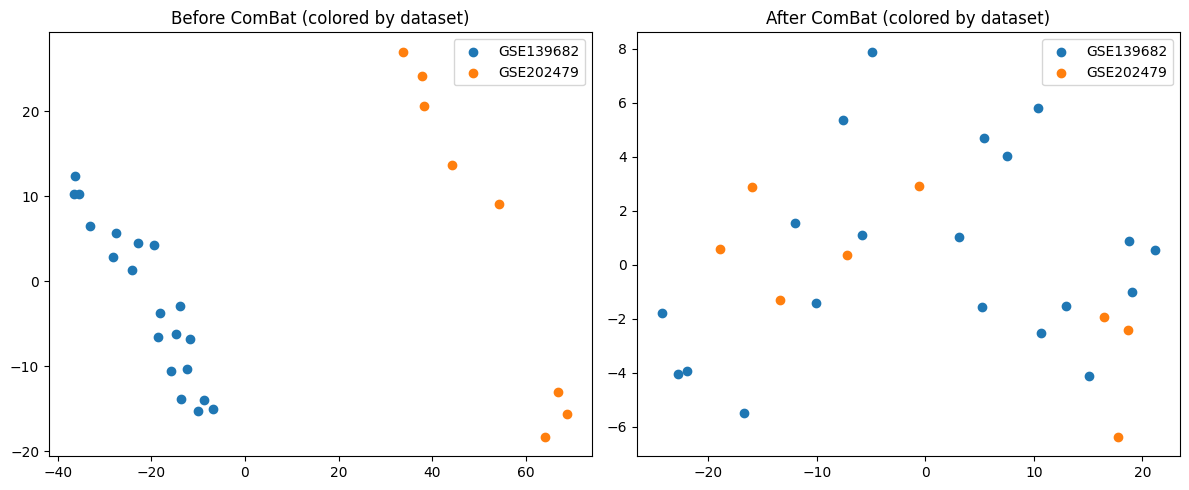

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = expr_corrected.drop(columns=['label', 'batch']).values
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Before correction, colored by batch (dataset)
X_before = combined_expr.drop(columns=['label','batch']).values
coords_before = PCA(n_components=2).fit_transform(X_before)
for batch in combined_expr['batch'].unique():
    idx = combined_expr['batch'] == batch
    axes[0].scatter(coords_before[idx,0], coords_before[idx,1], label=batch)
axes[0].set_title('Before ComBat (colored by dataset)')
axes[0].legend()

# After correction, colored by batch
for batch in expr_corrected['batch'].unique():
    idx = expr_corrected['batch'] == batch
    axes[1].scatter(coords[idx,0], coords[idx,1], label=batch)
axes[1].set_title('After ComBat (colored by dataset)')
axes[1].legend()

plt.tight_layout()
plt.show()